In [3]:
import xarray as xr

ds1 = xr.open_dataset(r'..\data\raw\data_stream-moda_stepType-avgua.nc')
print("=== avgua (averages) ===")
print(ds1.data_vars)

ds2 = xr.open_dataset(r'..\data\raw\data_stream-moda_stepType-avgad.nc')
print("=== avgad (accumulated) ===")
print(ds2.data_vars)

=== avgua (averages) ===
Data variables:
    t2m      (valid_time, latitude, longitude) float32 4GB ...
=== avgad (accumulated) ===
Data variables:
    tp       (valid_time, latitude, longitude) float32 4GB ...
    ssrd     (valid_time, latitude, longitude) float32 4GB ...


In [4]:
print(f"Time range: {ds1.valid_time.values[0]} → {ds1.valid_time.values[-1]}")
print(f"Number of time steps: {len(ds1.valid_time)}")
print(f"Lat range: {ds1.latitude.values.min()} to {ds1.latitude.values.max()}")
print(f"Lon range: {ds1.longitude.values.min()} to {ds1.longitude.values.max()}")
print(f"Grid size: {len(ds1.latitude)} x {len(ds1.longitude)}")

Time range: 1940-01-01T00:00:00.000000000 → 2025-12-01T00:00:00.000000000
Number of time steps: 1032
Lat range: -90.0 to 90.0
Lon range: 0.0 to 359.75
Grid size: 721 x 1440


In [5]:
# First, convert the longitude from 0-360 to -180-180
ds1 = ds1.assign_coords(longitude=(((ds1.longitude + 180) % 360) - 180))
ds1 = ds1.sortby('longitude')

ds2 = ds2.assign_coords(longitude=(((ds2.longitude + 180) % 360) - 180))
ds2 = ds2.sortby('longitude')

# Now slice to Europe
ds1_eu = ds1.sel(latitude=slice(72, 34), longitude=slice(-25, 45))
ds2_eu = ds2.sel(latitude=slice(72, 34), longitude=slice(-25, 45))

print(f"Grid size: {len(ds1_eu.latitude)} x {len(ds1_eu.longitude)}")

Grid size: 153 x 281


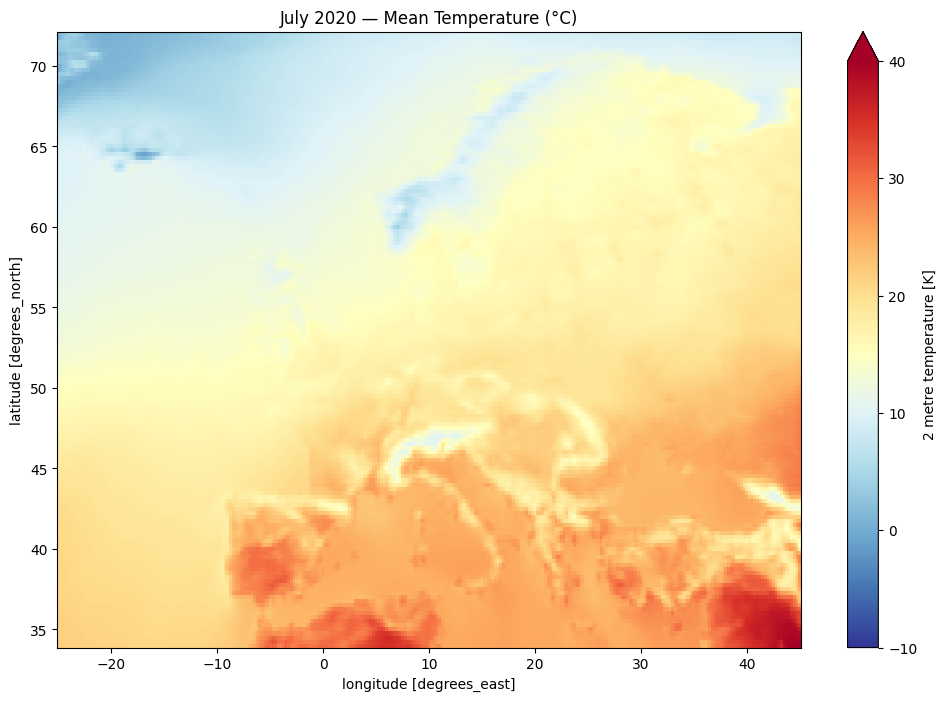

In [6]:
import matplotlib.pyplot as plt

temp = ds1_eu['t2m'].sel(valid_time='2020-07') - 273.15

temp.plot(figsize=(12, 8), cmap='RdYlBu_r', vmin=-10, vmax=40)
plt.title('July 2020 — Mean Temperature (°C)')
plt.show()

In [1]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://climate-api.open-meteo.com/v1/climate"
params = {
    "latitude": 48.86,
    "longitude": 2.35,
    "start_date": "1991-01-01",
    "end_date": "2050-12-31",
    "models": ["CMCC_CM2_VHR4", "EC_Earth3P_HR", "MPI_ESM1_2_XR", "MRI_AGCM3_2_S"],
    "daily": ["temperature_2m_mean", "temperature_2m_max", "precipitation_sum"],
}

responses = openmeteo.weather_api(url, params=params)

# Just check the first model's response
response = responses[0]
print(f"Model: {response.Model()}")
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")

daily = response.Daily()
daily_data = {
    "date": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ),
    "temperature_2m_mean": daily.Variables(0).ValuesAsNumpy(),
    "temperature_2m_max": daily.Variables(1).ValuesAsNumpy(),
    "precipitation_sum": daily.Variables(2).ValuesAsNumpy(),
}

df = pd.DataFrame(data=daily_data)
print(f"Rows: {len(df)}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(df.head(10))

Model: 41
Coordinates: 48.90000915527344°N 2.4000091552734375°E
Rows: 21915
Date range: 1991-01-01 00:00:00+00:00 → 2050-12-31 00:00:00+00:00
                       date  temperature_2m_mean  temperature_2m_max  \
0 1991-01-01 00:00:00+00:00             8.478718           10.865423   
1 1991-01-02 00:00:00+00:00             7.475815           10.266903   
2 1991-01-03 00:00:00+00:00             2.430306            5.978294   
3 1991-01-04 00:00:00+00:00             0.084796            2.439685   
4 1991-01-05 00:00:00+00:00            -0.310713            1.451074   
5 1991-01-06 00:00:00+00:00            -0.656223            1.412465   
6 1991-01-07 00:00:00+00:00             2.348269            7.623856   
7 1991-01-08 00:00:00+00:00             4.602759            6.735246   
8 1991-01-09 00:00:00+00:00             4.907249            7.346636   
9 1991-01-10 00:00:00+00:00             4.811740            9.358027   

   precipitation_sum  
0           7.256443  
1          11.93028

In [2]:
import pandas as pd
from geopy.geocoders import Nominatim
import time

# Load your Numbeo data
costs = pd.read_csv(r'..\data\raw\cost-of-living.csv')

print(f"Total cities: {len(costs)}")
print(costs[['city', 'country']].head(10))

geolocator = Nominatim(user_agent="europe-climate-bi")

coords = []
for i, row in costs.iterrows():
    try:
        location = geolocator.geocode(f"{row['city']}, {row['country']}")
        if location:
            coords.append({
                "city": row["city"],
                "country": row["country"],
                "lat": round(location.latitude, 4),
                "lon": round(location.longitude, 4)
            })
            print(f"✓ {i+1}/{len(costs)} {row['city']} → {location.latitude:.4f}, {location.longitude:.4f}")
        else:
            coords.append({"city": row["city"], "country": row["country"],
                          "lat": None, "lon": None})
            print(f"✗ {i+1}/{len(costs)} {row['city']} → NOT FOUND")
        time.sleep(1)  # Nominatim requires 1 second between requests
    except Exception as e:
        print(f"✗ {i+1}/{len(costs)} {row['city']} → ERROR: {e}")
        coords.append({"city": row["city"], "country": row["country"],
                      "lat": None, "lon": None})
        time.sleep(1)

cities = pd.DataFrame(coords)

# Check for any missing coordinates
missing = cities[cities['lat'].isna()]
print(f"\nMissing coordinates: {len(missing)}")
if len(missing) > 0:
    print(missing[['city', 'country']])

# Save master table
cities.to_csv(r'..\data\processed\cities_master.csv', index=False)
print(f"\nSaved {len(cities)} cities to cities_master.csv")

Total cities: 231
        city       country
0     Zurich   Switzerland
1     Geneva   Switzerland
2      Basel   Switzerland
3   Lausanne   Switzerland
4     Lugano   Switzerland
5       Bern   Switzerland
6  Reykjavik       Iceland
7       Oslo        Norway
8  Trondheim        Norway
9     Bergen        Norway
✓ 1/231 Zurich → 47.3744, 8.5410
✓ 2/231 Geneva → 46.2018, 6.1466
✓ 3/231 Basel → 47.5581, 7.5878
✓ 4/231 Lausanne → 46.5218, 6.6327
✓ 5/231 Lugano → 46.0050, 8.9520
✓ 6/231 Bern → 46.9485, 7.4522
✓ 7/231 Reykjavik → 64.1460, -21.9422
✓ 8/231 Oslo → 59.9133, 10.7390
✓ 9/231 Trondheim → 63.4304, 10.3952
✓ 10/231 Bergen → 60.3943, 5.3259
✓ 11/231 London → 51.5074, -0.1278
✓ 12/231 Stavanger → 58.9700, 5.7318
✓ 13/231 Copenhagen → 55.6867, 12.5701
✓ 14/231 Amsterdam → 52.3731, 4.8925
✓ 15/231 Pisa → 43.4715, 10.6798
✓ 16/231 Stockholm → 59.3251, 18.0711
✓ 17/231 Luxembourg → 49.8159, 6.1297
✓ 18/231 Haarlem → 52.3837, 4.6436
✓ 19/231 Aalborg → 57.0463, 9.9215
✓ 20/231 Aarhus → 56

In [2]:
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry
import numpy as np

# Load master city table
cities = pd.read_csv(r'..\data\processed\cities_master.csv')
cities = cities.dropna(subset=['lat', 'lon'])

# Setup API client
cache_session = requests_cache.CachedSession('.cache', expire_after=86400)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://climate-api.open-meteo.com/v1/climate"
models = ["CMCC_CM2_VHR4", "EC_Earth3P_HR", "MPI_ESM1_2_XR", "MRI_AGCM3_2_S"]
n_models = len(models)

# Batch request — all cities at once
params = {
    "latitude": cities["lat"].tolist(),
    "longitude": cities["lon"].tolist(),
    "start_date": "1991-01-01",
    "end_date": "2050-12-31",
    "models": models,
    "daily": ["temperature_2m_mean", "temperature_2m_max", "precipitation_sum"],
}

print(f"Fetching data for {len(cities)} cities × {n_models} models...")
responses = openmeteo.weather_api(url, params=params)
print(f"Received {len(responses)} responses")

# Process: responses are ordered as [city1_model1, city1_model2, ..., city1_model4, city2_model1, ...]
all_results = []

for city_idx in range(len(cities)):
    row = cities.iloc[city_idx]
    city_responses = responses[city_idx * n_models : (city_idx + 1) * n_models]

    try:
        model_dfs = []
        for response in city_responses:
            daily = response.Daily()
            df = pd.DataFrame({
                "date": pd.date_range(
                    start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                    end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                    freq=pd.Timedelta(seconds=daily.Interval()),
                    inclusive="left"
                ),
                "temperature_2m_mean": daily.Variables(0).ValuesAsNumpy(),
                "temperature_2m_max": daily.Variables(1).ValuesAsNumpy(),
                "precipitation_sum": daily.Variables(2).ValuesAsNumpy(),
            })
            model_dfs.append(df)

        # Ensemble mean across models
        ensemble = pd.concat(model_dfs)
        ensemble_mean = ensemble.groupby("date").agg({
            "temperature_2m_mean": "mean",
            "temperature_2m_max": "mean",
            "precipitation_sum": "mean"
        }).reset_index()

        ensemble_mean["month"] = ensemble_mean["date"].dt.month
        ensemble_mean["year"] = ensemble_mean["date"].dt.year

        baseline = ensemble_mean[(ensemble_mean["year"] >= 1991) & (ensemble_mean["year"] <= 2020)]
        future = ensemble_mean[(ensemble_mean["year"] >= 2040) & (ensemble_mean["year"] <= 2050)]

        # Annual temperature change
        baseline_temp = baseline["temperature_2m_mean"].mean()
        future_temp = future["temperature_2m_mean"].mean()
        delta_temp = future_temp - baseline_temp

        # Summer temperature change
        baseline_summer = baseline[baseline["month"].isin([6, 7, 8])]["temperature_2m_mean"].mean()
        future_summer = future[future["month"].isin([6, 7, 8])]["temperature_2m_mean"].mean()
        delta_summer = future_summer - baseline_summer

        # Precipitation change (%)
        baseline_precip = baseline.groupby("year")["precipitation_sum"].sum().mean()
        future_precip = future.groupby("year")["precipitation_sum"].sum().mean()
        delta_precip_pct = ((future_precip - baseline_precip) / baseline_precip) * 100

        # Extreme heat days change
        baseline_heat = baseline[baseline["temperature_2m_max"] > 35].groupby("year").size().mean()
        future_heat = future[future["temperature_2m_max"] > 35].groupby("year").size().mean()
        if np.isnan(baseline_heat): baseline_heat = 0
        if np.isnan(future_heat): future_heat = 0
        delta_heat_days = future_heat - baseline_heat

        all_results.append({
            "city": row["city"],
            "country": row["country"],
            "lat": row["lat"],
            "lon": row["lon"],
            "baseline_temp_c": round(baseline_temp, 1),
            "future_temp_c": round(future_temp, 1),
            "delta_temp_c": round(delta_temp, 1),
            "delta_summer_temp_c": round(delta_summer, 1),
            "delta_precip_pct": round(delta_precip_pct, 1),
            "baseline_heat_days": round(baseline_heat, 1),
            "future_heat_days": round(future_heat, 1),
            "delta_heat_days": round(delta_heat_days, 1),
        })

        print(f"✓ {city_idx+1}/{len(cities)} {row['city']}: ΔT={delta_temp:+.1f}°C, ΔP={delta_precip_pct:+.1f}%, ΔHeat={delta_heat_days:+.1f} days")

    except Exception as e:
        print(f"✗ {city_idx+1}/{len(cities)} {row['city']}: ERROR - {e}")

# Save
projections = pd.DataFrame(all_results)
projections.to_csv(r'..\data\processed\climate_projections.csv', index=False)
print(f"\nSaved projections for {len(projections)} cities")
print(projections.head(10))

Fetching data for 230 cities × 4 models...
Received 920 responses
✓ 1/230 Zurich: ΔT=+1.7°C, ΔP=-4.3%, ΔHeat=+0.0 days
✓ 2/230 Geneva: ΔT=+1.8°C, ΔP=-8.0%, ΔHeat=+0.0 days
✓ 3/230 Basel: ΔT=+1.8°C, ΔP=-4.1%, ΔHeat=+1.0 days
✓ 4/230 Lausanne: ΔT=+1.8°C, ΔP=-6.5%, ΔHeat=+0.0 days
✓ 5/230 Lugano: ΔT=+1.7°C, ΔP=-11.0%, ΔHeat=+0.0 days
✓ 6/230 Bern: ΔT=+1.8°C, ΔP=-4.9%, ΔHeat=+0.0 days
✓ 7/230 Reykjavik: ΔT=+1.1°C, ΔP=+5.6%, ΔHeat=+0.0 days
✓ 8/230 Oslo: ΔT=+1.8°C, ΔP=+0.3%, ΔHeat=+0.0 days
✓ 9/230 Trondheim: ΔT=+1.5°C, ΔP=+6.3%, ΔHeat=+0.0 days
✓ 10/230 Bergen: ΔT=+1.2°C, ΔP=+5.3%, ΔHeat=+0.0 days
✓ 11/230 London: ΔT=+1.3°C, ΔP=-1.6%, ΔHeat=+0.0 days
✓ 12/230 Stavanger: ΔT=+1.1°C, ΔP=+3.2%, ΔHeat=+0.0 days
✓ 13/230 Copenhagen: ΔT=+1.6°C, ΔP=-1.1%, ΔHeat=+0.0 days
✓ 14/230 Amsterdam: ΔT=+1.3°C, ΔP=-3.0%, ΔHeat=+0.0 days
✓ 15/230 Pisa: ΔT=+1.7°C, ΔP=-10.6%, ΔHeat=+3.1 days
✓ 16/230 Stockholm: ΔT=+1.8°C, ΔP=-1.8%, ΔHeat=+0.0 days
✓ 17/230 Luxembourg: ΔT=+1.7°C, ΔP=-6.1%, ΔHeat=+0.0 days
✓ 18/

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import json
import os

# ============================================================
# 1. LOAD THE DATA
# ============================================================
print("Loading NetCDF files...", flush=True)
ds1 = xr.open_dataset(r'..\data\raw\data_stream-moda_stepType-avgua.nc')
ds2 = xr.open_dataset(r'..\data\raw\data_stream-moda_stepType-avgad.nc')

# Fix longitude from 0-360 to -180-180
ds1 = ds1.assign_coords(longitude=(((ds1.longitude + 180) % 360) - 180)).sortby('longitude')
ds2 = ds2.assign_coords(longitude=(((ds2.longitude + 180) % 360) - 180)).sortby('longitude')

# Slice to Europe
ds1_eu = ds1.sel(latitude=slice(72, 34), longitude=slice(-25, 45))
ds2_eu = ds2.sel(latitude=slice(72, 34), longitude=slice(-25, 45))

print(f"Temperature shape: {ds1_eu['t2m'].shape}", flush=True)
print(f"Precipitation shape: {ds2_eu['tp'].shape}", flush=True)
print(f"SSRD shape: {ds2_eu['ssrd'].shape}", flush=True)

# ============================================================
# 2. UNIT CONVERSIONS
# ============================================================
print("\nConverting units...", flush=True)

# Temperature: Kelvin → Celsius
temp_c = ds1_eu['t2m'] - 273.15

# Precipitation: metres → mm/month
days_in_month = ds2_eu['valid_time'].dt.days_in_month
precip_mm = ds2_eu['tp'] * 1000 * days_in_month

print("Temperature and precipitation converted.", flush=True)

# ============================================================
# 3. SUNSHINE HOURS ESTIMATION (Vectorized Ångström-Prescott)
# ============================================================
print("\nComputing sunshine hours (vectorized)...", flush=True)

# Precompute daylight hours and clear-sky radiation for each month × latitude
mid_doy = np.array([15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349])
Gsc = 1361  # Solar constant (W/m²)

lats = ds2_eu.latitude.values
lat_rad = np.radians(lats)  # shape: (153,)

daylight_lookup = np.zeros((12, len(lats)))
clearsky_lookup = np.zeros((12, len(lats)))

for m in range(12):
    doy = mid_doy[m]
    decl = np.radians(23.45 * np.sin(np.radians(360 * (284 + doy) / 365)))
    dr = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)

    cos_ws = -np.tan(lat_rad) * np.tan(decl)
    cos_ws = np.clip(cos_ws, -1, 1)
    ws = np.arccos(cos_ws)

    daylight_lookup[m, :] = (24 / np.pi) * ws
    clearsky_lookup[m, :] = (24 * 3600 / np.pi) * Gsc * dr * (
        ws * np.sin(lat_rad) * np.sin(decl) +
        np.cos(lat_rad) * np.cos(decl) * np.sin(ws)
    )

print("Lookup tables built.", flush=True)

# Load SSRD into memory
print("Loading SSRD into memory...", flush=True)
ssrd_vals = ds2_eu['ssrd'].values
print(f"SSRD loaded: {ssrd_vals.shape}", flush=True)

# Get month index (0-based) for each time step
month_idx = ds2_eu['valid_time'].dt.month.values - 1  # shape: (1032,)

# Build arrays matching (time, lat) then broadcast to (time, lat, lon)
dl_array = daylight_lookup[month_idx, :]   # (1032, 153)
ra_array = clearsky_lookup[month_idx, :]   # (1032, 153)

dl_3d = dl_array[:, :, np.newaxis]         # (1032, 153, 1)
ra_3d = ra_array[:, :, np.newaxis]         # (1032, 153, 1)

# Compute sunshine fraction and hours
fraction = np.where(ra_3d > 0, ssrd_vals / (0.75 * ra_3d), 0)
fraction = np.clip(fraction, 0, 1)
sunshine = fraction * dl_3d
sunshine = np.clip(sunshine, 0, 16)

# Create xarray DataArray
sunshine_da = xr.DataArray(
    sunshine,
    coords=ds2_eu['ssrd'].coords,
    dims=ds2_eu['ssrd'].dims,
    name='sunshine_hours'
)

print(f"Sunshine computed. Range: {sunshine.min():.1f} to {sunshine.max():.1f} h/day", flush=True)
print(f"July 2020 Mediterranean (lat=37, lon=0): {float(sunshine_da.sel(valid_time='2020-07', latitude=37, longitude=0, method='nearest')):.1f} h/day", flush=True)
print(f"Jan 2020 Stockholm (lat=59, lon=18): {float(sunshine_da.sel(valid_time='2020-01', latitude=59, longitude=18, method='nearest')):.1f} h/day", flush=True)

# ============================================================
# 4. COMPUTE CLIMATE NORMALS (1991-2020)
# ============================================================
print("\nComputing 1991-2020 climate normals...", flush=True)

# Filter to 1991-2020
temp_norm = temp_c.sel(valid_time=slice('1991-01', '2020-12'))
precip_norm = precip_mm.sel(valid_time=slice('1991-01', '2020-12'))
sunshine_norm = sunshine_da.sel(valid_time=slice('1991-01', '2020-12'))

# Group by month and take mean → 12 "typical month" grids
temp_normals = temp_norm.groupby('valid_time.month').mean('valid_time')
precip_normals = precip_norm.groupby('valid_time.month').mean('valid_time')
sunshine_normals = sunshine_norm.groupby('valid_time.month').mean('valid_time')

print(f"Normals shape: {temp_normals.shape}", flush=True)
print(f"\n--- SANITY CHECKS ---", flush=True)
print(f"July normal temp:     {float(temp_normals.sel(month=7).min()):.1f}°C to {float(temp_normals.sel(month=7).max()):.1f}°C", flush=True)
print(f"July normal precip:   {float(precip_normals.sel(month=7).min()):.1f}mm to {float(precip_normals.sel(month=7).max()):.1f}mm", flush=True)
print(f"July normal sunshine: {float(sunshine_normals.sel(month=7).min()):.1f}h to {float(sunshine_normals.sel(month=7).max()):.1f}h/day", flush=True)
print(f"Jan normal temp:      {float(temp_normals.sel(month=1).min()):.1f}°C to {float(temp_normals.sel(month=1).max()):.1f}°C", flush=True)
print(f"Jan normal precip:    {float(precip_normals.sel(month=1).min()):.1f}mm to {float(precip_normals.sel(month=1).max()):.1f}mm", flush=True)
print(f"Jan normal sunshine:  {float(sunshine_normals.sel(month=1).min()):.1f}h to {float(sunshine_normals.sel(month=1).max()):.1f}h/day", flush=True)

print("\n✓ Processing complete!", flush=True)

Loading NetCDF files...
Temperature shape: (1032, 153, 281)
Precipitation shape: (1032, 153, 281)
SSRD shape: (1032, 153, 281)

Converting units...
Temperature and precipitation converted.

Computing sunshine hours (vectorized)...
Lookup tables built.
Loading SSRD into memory...
SSRD loaded: (1032, 153, 281)


C:\Users\cleme\AppData\Local\Temp\ipykernel_18120\3530643431.py:88: RuntimeWarning: divide by zero encountered in divide
  fraction = np.where(ra_3d > 0, ssrd_vals / (0.75 * ra_3d), 0)
C:\Users\cleme\AppData\Local\Temp\ipykernel_18120\3530643431.py:88: RuntimeWarning: invalid value encountered in divide
  fraction = np.where(ra_3d > 0, ssrd_vals / (0.75 * ra_3d), 0)


Sunshine computed. Range: 0.0 to 16.0 h/day
July 2020 Mediterranean (lat=37, lon=0): 12.7 h/day
Jan 2020 Stockholm (lat=59, lon=18): 3.0 h/day

Computing 1991-2020 climate normals...
Normals shape: (12, 153, 281)

--- SANITY CHECKS ---
July normal temp:     0.2°C to 38.5°C
July normal precip:   0.0mm to 406.4mm
July normal sunshine: 7.9h to 16.0h/day
Jan normal temp:      -21.5°C to 17.5°C
Jan normal precip:    11.2mm to 339.9mm
Jan normal sunshine:  0.0h to 8.8h/day

✓ Processing complete!


In [4]:
import os
import json
import numpy as np

# ============================================================
# EXPORT CLIMATE NORMALS AS JSON FOR FRONTEND
# ============================================================

output_dir = r'..\data\processed\climate_normals'
os.makedirs(output_dir, exist_ok=True)

lats = temp_normals.latitude.values
lons = temp_normals.longitude.values

# Round coordinates to save space
lats_list = [round(float(l), 2) for l in lats]
lons_list = [round(float(l), 2) for l in lons]

month_names = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

for m in range(1, 13):
    name = month_names[m - 1]
    
    # Extract the grid for this month
    temp_grid = temp_normals.sel(month=m).values       # (153, 281)
    precip_grid = precip_normals.sel(month=m).values
    sun_grid = sunshine_normals.sel(month=m).values
    
    # Replace NaN with null-friendly value
    temp_grid = np.where(np.isnan(temp_grid), None, np.round(temp_grid, 1))
    precip_grid = np.where(np.isnan(precip_grid), None, np.round(precip_grid, 1))
    sun_grid = np.where(np.isnan(sun_grid), None, np.round(sun_grid, 1))
    
    # Structure: compact grid format
    # The frontend knows the lat/lon arrays and reconstructs the grid
    data = {
        "month": m,
        "lats": lats_list,
        "lons": lons_list,
        "temperature": temp_grid.tolist(),
        "precipitation": precip_grid.tolist(),
        "sunshine": sun_grid.tolist(),
    }
    
    filepath = os.path.join(output_dir, f'climate_{name}.json')
    with open(filepath, 'w') as f:
        json.dump(data, f, separators=(',', ':'))  # No whitespace = smaller file
    
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"✓ {name}: {size_mb:.1f} MB", flush=True)

# Also export a metadata file
meta = {
    "lats": lats_list,
    "lons": lons_list,
    "n_lat": len(lats_list),
    "n_lon": len(lons_list),
    "variables": ["temperature", "precipitation", "sunshine"],
    "units": {
        "temperature": "°C",
        "precipitation": "mm/month",
        "sunshine": "hours/day"
    },
    "baseline_period": "1991-2020",
    "months": month_names,
}

with open(os.path.join(output_dir, 'metadata.json'), 'w') as f:
    json.dump(meta, f, indent=2)

total_size = sum(
    os.path.getsize(os.path.join(output_dir, f))
    for f in os.listdir(output_dir)
) / (1024 * 1024)

print(f"\n✓ Export complete. {len(os.listdir(output_dir))} files, {total_size:.1f} MB total", flush=True)

✓ jan: 1.0 MB
✓ feb: 1.0 MB
✓ mar: 1.0 MB
✓ apr: 1.0 MB
✓ may: 1.1 MB
✓ jun: 1.1 MB
✓ jul: 1.1 MB
✓ aug: 1.0 MB
✓ sep: 1.0 MB
✓ oct: 1.0 MB
✓ nov: 1.0 MB
✓ dec: 1.0 MB

✓ Export complete. 13 files, 12.5 MB total


In [5]:
import pandas as pd
import numpy as np
import json
import os

# ============================================================
# 1. LOAD DATA
# ============================================================
projections = pd.read_csv(r'..\data\processed\climate_projections.csv')
costs = pd.read_csv(r'..\data\raw\cost-of-living.csv')
cities = pd.read_csv(r'..\data\processed\cities_master.csv')

print(f"Projections: {len(projections)} cities", flush=True)
print(f"Cost of living: {len(costs)} cities", flush=True)
print(f"Master city list: {len(cities)} cities", flush=True)

# ============================================================
# 2. COMPUTE RESILIENCE SCORE
# ============================================================

# The score uses 4 metrics from the projections:
# - delta_temp_c: higher = worse (more warming)
# - delta_summer_temp_c: higher = worse
# - delta_precip_pct: further from 0 = worse (both drought and flooding)
# - delta_heat_days: higher = worse (more extreme heat)

df = projections.copy()

# Normalize each metric to 0-100 (0 = best, 100 = worst)

# Temperature change: min-max scale
df['temp_score'] = (df['delta_temp_c'] - df['delta_temp_c'].min()) / \
                   (df['delta_temp_c'].max() - df['delta_temp_c'].min()) * 100

# Summer temperature change
df['summer_score'] = (df['delta_summer_temp_c'] - df['delta_summer_temp_c'].min()) / \
                     (df['delta_summer_temp_c'].max() - df['delta_summer_temp_c'].min()) * 100

# Precipitation: absolute change matters (both drying and flooding are bad)
df['precip_severity'] = df['delta_precip_pct'].abs()
df['precip_score'] = (df['precip_severity'] - df['precip_severity'].min()) / \
                     (df['precip_severity'].max() - df['precip_severity'].min()) * 100

# Extreme heat days
df['heat_score'] = (df['delta_heat_days'] - df['delta_heat_days'].min()) / \
                   (df['delta_heat_days'].max() - df['delta_heat_days'].min()) * 100

# Weighted composite: 0 = most vulnerable, 100 = most resilient
# Higher sub-scores = worse, so we invert
weights = {
    'temp_score': 0.25,
    'summer_score': 0.25,
    'precip_score': 0.25,
    'heat_score': 0.25
}

df['vulnerability'] = sum(df[k] * v for k, v in weights.items())
df['resilience_score'] = round(100 - df['vulnerability'], 1)

# Assign risk tiers
def assign_tier(score):
    if score >= 75:
        return 'Low Risk'
    elif score >= 50:
        return 'Moderate Risk'
    elif score >= 25:
        return 'High Risk'
    else:
        return 'Critical'

df['risk_tier'] = df['resilience_score'].apply(assign_tier)

# Save updated projections
cols_to_save = [
    'city', 'country', 'lat', 'lon',
    'baseline_temp_c', 'future_temp_c',
    'delta_temp_c', 'delta_summer_temp_c',
    'delta_precip_pct',
    'baseline_heat_days', 'future_heat_days', 'delta_heat_days',
    'resilience_score', 'risk_tier'
]
df[cols_to_save].to_csv(r'..\data\processed\climate_projections.csv', index=False)

# Print distribution
print(f"\nResilience score range: {df['resilience_score'].min()} to {df['resilience_score'].max()}", flush=True)
print(f"\nRisk tier distribution:", flush=True)
print(df['risk_tier'].value_counts().to_string(), flush=True)
print(f"\nMost resilient cities:", flush=True)
print(df.nlargest(5, 'resilience_score')[['city', 'country', 'resilience_score', 'risk_tier']].to_string(index=False), flush=True)
print(f"\nMost vulnerable cities:", flush=True)
print(df.nsmallest(5, 'resilience_score')[['city', 'country', 'resilience_score', 'risk_tier']].to_string(index=False), flush=True)

# ============================================================
# 3. MERGE INTO ONE CITY JSON FOR FRONTEND
# ============================================================

# Start from the master city list
merged = cities.copy()

# Merge cost of living
merged = merged.merge(costs, on=['city', 'country'], how='left')

# Merge projections + resilience
proj_cols = df[cols_to_save].drop(columns=['lat', 'lon'])  # Avoid duplicate lat/lon
merged = merged.merge(proj_cols, on=['city', 'country'], how='left')

# Convert to JSON-friendly format
# Replace NaN with None for clean JSON
merged = merged.where(merged.notna(), None)

# Round numeric columns
numeric_cols = merged.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    merged[col] = merged[col].apply(lambda x: round(x, 2) if x is not None else None)

# Export as JSON array
records = merged.to_dict(orient='records')

output_path = r'..\data\processed\cities_all.json'
with open(output_path, 'w') as f:
    json.dump(records, f, separators=(',', ':'))

size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"\n✓ Exported {len(records)} cities to cities_all.json ({size_mb:.2f} MB)", flush=True)

# Show what columns are in the final file
print(f"\nColumns in cities_all.json:", flush=True)
for col in merged.columns:
    non_null = merged[col].notna().sum()
    print(f"  {col}: {non_null}/{len(merged)} values", flush=True)

Projections: 230 cities
Cost of living: 231 cities
Master city list: 231 cities

Resilience score range: 24.7 to 97.0

Risk tier distribution:
risk_tier
Moderate Risk    146
Low Risk          59
High Risk         23
Critical           2

Most resilient cities:
                      city         country  resilience_score risk_tier
                    Dublin         Ireland              97.0  Low Risk
                   Belfast  United Kingdom              95.2  Low Risk
                    Galway         Ireland              94.2  Low Risk
                  Limerick         Ireland              94.0  Low Risk
Las Palmas de Gran Canaria           Spain              93.1  Low Risk

Most vulnerable cities:
    city country  resilience_score risk_tier
Cagliari   Italy              24.7  Critical
 Granada   Spain              24.7  Critical
    Rome   Italy              31.8 High Risk
 Bologna   Italy              34.1 High Risk
Florence   Italy              41.2 High Risk

✓ Exported 231 ci